# Alcanzando los objetivos de desarrollo sostenible. Un aporte desde el machine learning.

- Samir Eduardo Colpas Gonzales
- Federico Zea Gutierrez

## Problema a Resolver
 
Actualmente Entidades como el UNFPA recopilan grandes cantidades de información ciudadana para alinear las políticas públicas con los 17 Objetivos de Desarrollo Sostenible (ODS) de la ONU; sin embargo, analizar y clasificar manualmente estos textos es un proceso lento, costoso y que requiere de expertos. Para resolver este cuello de botella, el proyecto busca desarrollar una herramienta basada en Procesamiento de Lenguaje Natural (PLN) y Machine Learning que clasifique automáticamente cualquier texto en el ODS correspondiente, presentando los resultados en una interfaz sencilla que facilite y agilice la toma de decisiones gubernamentales.

In [155]:
import pandas as pd
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
import random

from sklearn.feature_extraction.text import TfidfVectorizer
from nltk import RegexpTokenizer
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV

In [156]:
nltk.download('punkt')
nltk.download('stopwords')

stop_words_es = set(stopwords.words('spanish'))

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\USUARIO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USUARIO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Preparación de datos

Todo proyecto de machine learning, ya sea supervisado o no supervisado, debe comenzar con la preparación de los datos. Habiendo entendido el problema, sabemos que nuestra información consiste en frases y palabras que deben ser clasificadas. Esto plantea un reto en sí mismo: aunque la preparación de datos de texto tiene similitudes con la de datos numéricos, debemos tener en cuenta que las palabras poseen un significado semántico que debe respetarse. Aun así, es necesario acondicionar el dataset para utilizarlo con los distintos modelos no supervisados. Para ello, planteamos el siguiente proceso:

1. **Limpieza de texto y Stop Words**: Primero, buscamos y eliminamos datos duplicados y valores nulos. Aunque en nuestro caso inicial no contamos con ellos, es una buena práctica ejecutar este paso para evitar ruido. Posteriormente, eliminamos las palabras "vacías" (conocidas en inglés como stop words). Estas son palabras de uso común, como "el", "la", "de" o "en", que no aportan un significado semántico relevante para la clasificación de los ODS, por lo que se descartan para limpiar la información.

2. **Stemming**: También aplicaremos un proceso de stemming. La idea principal es reducir las palabras a su raíz; por ejemplo, términos como "educación", "educar" y "educativo" comparten un mismo concepto base, lo que nos ayuda a agrupar palabras similares bajo una misma característica. Esto resulta muy útil en problemas donde tenemos textos cortos y variados, como ocurre en este dataset.
(Nota: Aunque Porter Stemmer es la herramienta más utilizada para este fin, fue diseñada originalmente para el idioma inglés. Por ello, tomamos la decisión técnica de utilizar Snowball Stemmer, que cuenta con soporte multilingüe, configurando el parámetro en español para adaptarlo a nuestros datos).

3. **TF-IDF**: Al analizar el problema, se podría pensar erróneamente que se soluciona con un conteo simple de palabras (es decir, tomar todas las palabras de los textos con sus etiquetas para ver cuáles se repiten más). Sin embargo, al hacer esto estaríamos cayendo directamente en la trampa del ruido. Los textos contienen muchas palabras frecuentes; al aplicar TF-IDF, logramos ponderar el texto y encontrar los términos que son verdaderamente distintivos para cada uno de los ODS, reduciendo la importancia de las palabras genéricas.

4. **Por qué usar Stemming y TF-IDF juntos**: A primera vista, se creería que ambos procesos son similares o redundantes, en el sentido de que "quitan" o "eliminan" información, lo cual podría parecer perjudicial si nuestro objetivo es alimentar al modelo con la mayor cantidad de datos posible. No obstante, la realidad es muy distinta: estas dos herramientas se utilizan de forma complementaria en la gran mayoría de proyectos de NLP. Primero, se prepara y normaliza el texto (stemming) y luego ese texto limpio se vectoriza numéricamente para que el modelo pueda interpretarlo.

    Si no utilizamos un stemmer previamente, el algoritmo TF-IDF tratará "gatos" y "gato" como dos palabras completamente distintas. Esto dividiría la frecuencia entre ambas, reduciendo su puntaje de importancia y provocando que el modelo sea más lento y menos preciso.

In [157]:
data = pd.read_excel('datos_miniproyecto2.xlsx')

In [158]:
data.head()

,textos,ODS
0,"""Aprendizaje"" y ""educación"" se consideran sinó...",4
1,No dejar clara la naturaleza de estos riesgos ...,6
2,"Como resultado, un mayor y mejorado acceso al ...",13
3,Con el Congreso firmemente en control de la ju...,16
4,"Luego, dos secciones finales analizan las impl...",5


In [159]:
data.duplicated().sum()

np.int64(0)

In [160]:
data.isna().sum()

textos    0
ODS       0
dtype: int64

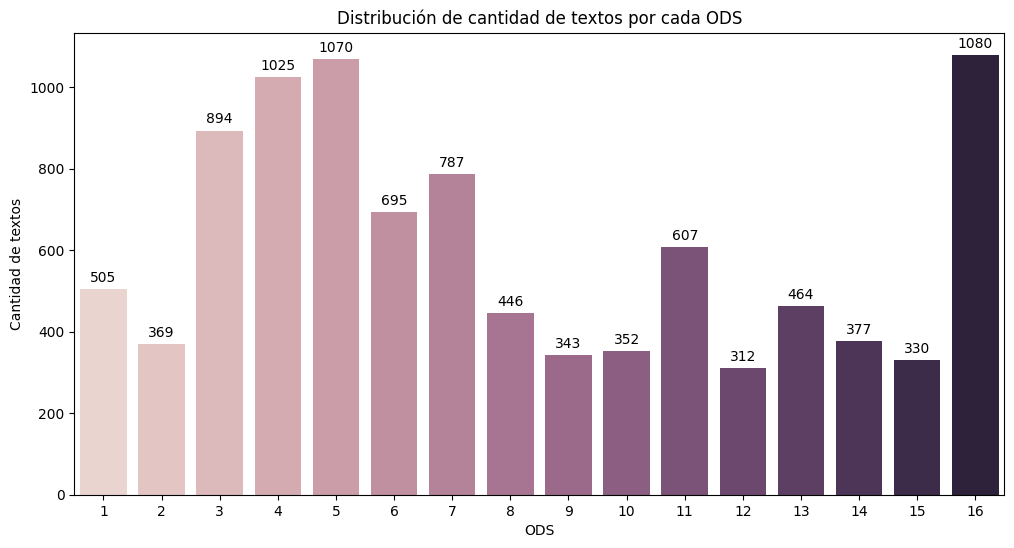

In [161]:

plt.figure(figsize=(12, 6))

ax = sns.countplot(data=data, x='ODS', hue='ODS', order=sorted(data['ODS'].unique()), legend=False)

plt.title('Distribución de cantidad de textos por cada ODS')
plt.xlabel('ODS')
plt.ylabel('Cantidad de textos')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=10, color='black', xytext=(0, 3), 
                textcoords='offset points')

plt.show()

In [162]:
X = data['textos']
y = data['ODS']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [163]:
_stop_words_es = set(stopwords.words("spanish"))
_tokenizer = RegexpTokenizer(r"\w+")
_stemmer = SnowballStemmer("spanish")

def text_preprocess(text):
    tokens = _tokenizer.tokenize(text)
    tokens = [word for word in tokens if word not in _stop_words_es]
    tokens = [_stemmer.stem(word) for word in tokens]
    return ' '.join(tokens)

In [164]:
vectorizer = TfidfVectorizer(preprocessor=text_preprocess)

In [165]:
tsvd = TruncatedSVD(n_components=100, random_state=42)

Por último, realizamos una reducción de dimensionalidad aplicando TruncatedSVD sobre la matriz TF-IDF. Este proceso opera identificando "conceptos" o "tópicos latentes". Por ejemplo, si dos palabras como "escuela" y "colegio" aparecen casi siempre en contextos similares, el algoritmo SVD las agrupa bajo un mismo concepto, disminuyendo así la cantidad de dimensiones necesarias para representar la información.

Esta gestión de la dimensionalidad es crucial porque la matriz generada por TF-IDF contiene miles de columnas (una por cada palabra distinta en nuestro dataset), pero la gran mayoría de sus valores son cero. En nuestro caso, utilizando el parámetro `n_components=100`, logramos reducir el espacio a solo 10 dimensiones. Esta fue una decisión técnica enfocada en optimizar el tiempo de cómputo y el uso de recursos.

Cabe destacar que se puede iterar con este parámetro para encontrar el balance ideal; el objetivo principal de este ajuste es disminuir el ruido y prevenir el sobreajuste, sin caer en un subajuste.

## Creación del pipeline y modelo de clasificación

Una vez que tenemos los datos listos y preparados, es momento de estructurar el pipeline y elegir el modelo de clasificación. Para este problema utilizaremos un modelo de regresión logística, ya que es una opción rápida, versátil y robusta para resolver problemas de clasificación de texto con clases linealmente separables.

No obstante, es necesario realizar algunos ajustes. El más importante de ellos es configurar el parámetro `class_weight='balanced'`. Como pudimos observar en el gráfico anterior, la distribución de los datos para cada uno de los ODS no es uniforme, lo que genera un claro desbalanceo entre las clases. Al utilizar este parámetro, el algoritmo penaliza con mayor severidad los errores cometidos en las clases minoritarias, obligando al modelo a prestarles más atención. Esto nos permite solventar el problema del desequilibrio sin tener que recurrir a otros enfoques que alteran el dataset, como la eliminación de datos o el submuestreo.

Además, como es bien sabido en machine learning, la búsqueda y optimización de hiperparámetros es un paso de vital importancia. rara vez un problema se soluciona de manera óptima utilizando los valores por defecto del modelo. Por este motivo, implementaremos un GridSearchCV con una validación cruzada de 5 particiones. Mediante este proceso, evaluaremos distintos valores de regularización para garantizar que el modelo generalice correctamente frente a datos nuevos, en lugar de simplemente aprenderse el conjunto de entrenamiento de memoria.

In [166]:
model = LogisticRegression(solver='lbfgs', max_iter=1000, class_weight='balanced')

In [167]:
steps = [
    ("vectorizer", vectorizer),
    ("dimred", tsvd),
    ("model", model),
]
pipeline = Pipeline(steps)

In [168]:
param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__max_iter': [500, 1000]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring="accuracy", n_jobs=-1, verbose=2)

In [169]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__max_iter': [500, 1000]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displa

In [170]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

In [171]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.80      0.80      0.80        90
           2       0.74      0.87      0.80        71
           3       0.91      0.87      0.89       178
           4       0.95      0.95      0.95       200
           5       0.96      0.85      0.90       232
           6       0.95      0.90      0.92       135
           7       0.94      0.83      0.88       164
           8       0.59      0.71      0.64        86
           9       0.61      0.85      0.71        55
          10       0.53      0.60      0.56        60
          11       0.86      0.75      0.80       143
          12       0.82      0.84      0.83        64
          13       0.84      0.86      0.85       102
          14       0.91      0.92      0.91        64
          15       0.96      0.96      0.96        81
          16       0.94      0.98      0.96       207

    accuracy                           0.86      1932
   macro avg       0.83   

In [172]:
ejemplos_indices = X_test.sample(n=4, random_state=55).index

for i, idx in enumerate(ejemplos_indices, 1):
    texto_prueba = X_test.loc[idx]
    ods_real = y_test.loc[idx]
    
    ods_predicho = best_model.predict([texto_prueba])[0]
    
    print(f"Ejemplo {i}:")
    print(f"Texto: \"{texto_prueba[:300]}...\"") 
    print(f"ODS Real: {ods_real} | ODS Predicho: {ods_predicho}")
    print("-" * 80)

Ejemplo 1:
Texto: "Del mismo modo, en Austria y Alemania, las barreras lingüísticas al bienestar social fueron mayores entre los alumnos inmigrantes de primera generación. Las diferencias socioeconómicas entre inmigrantes y nativos explican casi una cuarta parte de las diferencias observadas en el rendimiento académic..."
ODS Real: 4 | ODS Predicho: 4
--------------------------------------------------------------------------------
Ejemplo 2:
Texto: "Este ensayo trata sobre los derechos sociales, económicos y culturales y los derechos políticos y civiles en el contexto del derecho internacional de los derechos humanos. Para ello, revisa la concepción contemporánea de este tema a la luz del sistema internacional de protección, evaluando su perfil..."
ODS Real: 16 | ODS Predicho: 16
--------------------------------------------------------------------------------
Ejemplo 3:
Texto: "Como se discutió en el Capítulo 2, luego de la intervención en Kosovo y la subsiguiente publicación de La Res

Una vez realizada la búsqueda de hiperparámetros, debemos entender el porqué de los resultados obtenidos. Actualmente nos enfrentamos a un problema multiclase con un claro desbalance de datos. En este contexto, guiarse únicamente por la accuracy puede ser engañoso, ya que esta métrica tiende a favorecer a las clases mayoritarias. Algo similar ocurre si solo observamos la recall para las clases minoritarias. Por ende, para este ejercicio es fundamental centrar nuestra atención en la métrica F1-Score, dado que proporciona un equilibrio adecuado entre precisión y recall.

¿Y cómo le fue a nuestro mejor modelo? Obtuvimos un promedio macro del 84% y un weighted avg del 86%. Estos resultados son muy positivos, ya que indican que el modelo es capaz de clasificar correctamente más del 80% de los textos en sus respectivos ODS. Además, una gran cantidad de clases presentan un rendimiento sobresaliente; por ejemplo, los ODS 15 y 16 alcanzan un 96%. De igual forma, es importante prestar atención a las clases 8 y 9, ya que son las que registran el F1-Score más bajo.

También es crucial entender la naturaleza del problema que buscamos solucionar. Aquí no enfrentamos un riesgo o costo por equivocación tan crítico como ocurriría en un diagnóstico médico o en una situación que vulnere los derechos fundamentales de una persona. Por lo tanto, clasificar correctamente más del 80% de los textos para la alineación de políticas públicas representa una gran ayuda, pues disminuirá significativamente la carga de analizar y categorizar los mensajes de forma manual.

Aun así, se recomienda implementar un enfoque de human-in-the-loop para auditar y gestionar ese porcentaje que el modelo clasifica erróneamente. Paralelamente, esto da margen para que el equipo de ingeniería pueda recolectar aún más datos o utilizar recursos computacionales más potentes para realizar una búsqueda de hiperparámetros mucho más exhaustiva en el futuro.

In [173]:
joblib.dump(best_model,'model/miniproject2-model.joblib')

['model/miniproject2-model.joblib']

# Tópicos

In [174]:
vectorizer_output = vectorizer.fit_transform(X)
vectorizer.get_feature_names_out()

array(['00', '000', '0000002', ..., 'ââ', 'ëoecoreââ', 'ñam'],
      shape=(18465,), dtype=object)

In [175]:
tsvd_output = tsvd.fit_transform(vectorizer_output)
tsvd_output

array([[ 0.11882066, -0.04888063, -0.00249045, ..., -0.00138014,
        -0.01501523, -0.02708207],
       [ 0.22772437,  0.28866795,  0.16048093, ...,  0.02455631,
         0.03603408, -0.01443947],
       [ 0.18196336,  0.11323213,  0.03969986, ..., -0.05862148,
        -0.05401128,  0.0141942 ],
       ...,
       [ 0.15123145,  0.022524  ,  0.00169988, ..., -0.03510746,
        -0.04501408, -0.05443015],
       [ 0.19400964,  0.09713956,  0.04990329, ..., -0.00805033,
         0.02355983, -0.01648201],
       [ 0.1199718 , -0.01690602, -0.01042118, ..., -0.06313168,
        -0.01529658, -0.06377173]], shape=(9656, 100))

In [176]:
vocabulario = vectorizer.get_feature_names_out()
loadings = tsvd.components_

n_palabras_por_topico = 10  
componentes_a_mostrar = 5   

topicos_dict = {}

for i in range(componentes_a_mostrar):
    indices_palabras_top = np.argsort(loadings[i])[::-1][:n_palabras_por_topico]
    palabras_top = [vocabulario[idx] for idx in indices_palabras_top]
    pesos_top = [loadings[i][idx] for idx in indices_palabras_top]
    palabras_con_peso = [f"{pal} ({peso:.4f})" for pal, peso in zip(palabras_top, pesos_top)]
    topicos_dict[f"Tópico {i + 1}"] = palabras_con_peso

df_topicos = pd.DataFrame(topicos_dict)
df_topicos.index = [f"Top {i+1}" for i in range(n_palabras_por_topico)]

display(df_topicos)

,Tópico 1,Tópico 2,Tópico 3,Tópico 4,Tópico 5
Top 1,pais (0.1392),agu (0.4277),derech (0.4900),mujer (0.3116),agu (0.6570)
Top 2,polit (0.1347),energ (0.2101),internacional (0.2238),agu (0.2833),educ (0.1234)
Top 3,pued (0.1309),cost (0.1143),human (0.2069),gener (0.1396),salud (0.1070)
Top 4,desarroll (0.1282),energet (0.0937),agu (0.1741),pobrez (0.1279),escuel (0.0956)
Top 5,mujer (0.1246),electr (0.0890),articul (0.1235),derech (0.1249),calid (0.0866)
Top 6,agu (0.1111),renov (0.0835),polit (0.1010),hombr (0.1241),atencion (0.0855)
Top 7,la (0.1085),gestion (0.0835),tribunal (0.0920),ingres (0.1149),hidric (0.0717)
Top 8,trabaj (0.1084),climat (0.0803),ley (0.0842),energ (0.1064),niñ (0.0708)
Top 9,educ (0.1053),eficient (0.0756),penal (0.0725),trabaj (0.0849),residual (0.0700)
Top 10,gener (0.1026),inversion (0.0720),nacional (0.0722),emple (0.0753),subterran (0.0689)


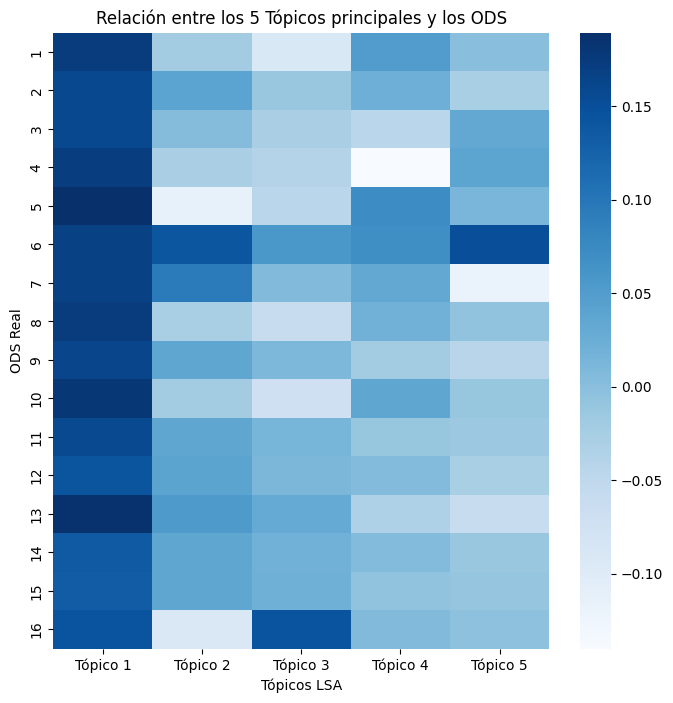

In [177]:
df_pesos_topicos = pd.DataFrame(tsvd_output)
df_pesos_topicos.columns = [f"Tópico {i+1}" for i in range(tsvd_output.shape[1])]

df_pesos_topicos['ODS_Real'] = y.reset_index(drop=True)
promedios_por_ods = df_pesos_topicos.groupby('ODS_Real').mean()

promedios_5_topicos = promedios_por_ods.iloc[:, :5]
plt.figure(figsize=(8, 8))
sns.heatmap(promedios_5_topicos, cmap="Blues", annot=False)

plt.title("Relación entre los 5 Tópicos principales y los ODS")
plt.xlabel("Tópicos LSA")
plt.ylabel("ODS Real")
plt.show()

Ahora podemos realizar un análisis de las palabras con mayor peso para cada uno de los tópicos mostrados. Sin embargo, primero debemos entender qué significa cada uno de los ODS que hemos clasificado; hasta ahora los hemos tratado simplemente como números, pero en realidad representan conceptos específicos. Para ello, tomamos como referencia: *Pacto Mundial de la ONU. (s.f.). ODS Objetivos de Desarrollo Sostenible. Recuperado el 18 de septiembre de 2026, de https://www.pactomundial.org/que-puedes-hacer-tu/ods/*

- **Tópico 1 - Palabras clave: pais, polit, desarroll, mujer, trabaj, educ, gener**: Este componente es muy transversal y captura la esencia general de la Agenda 2030. Agrupa vocabulario relacionado con políticas a nivel país y desarrollo. Se relaciona fuertemente con una mezcla del ODS 5 (gualdad de género:) y el ODS 13 (Acción por el clima)

- **Tópico 2 - Palabras clave: energ, energet, electr, renov, gestion, climat, eficient, inversion**: Este tópico tiene una identidad muy definida. Agrupa términos clave sobre fuentes de energía, electricidad renovable, eficiencia climática e inversión. Esto se asocia con el ODS 6 (Agua limpia y saneamiento) y ODS 7 (Energía asequible y no contaminante)

- **Tópico 3 - Palabras clave: derech, internacional, human, articul, tribunal, ley, penal, nacional**: El modelo logró agrupar a la perfección el lenguaje jurídico y de derechos fundamentales. Palabras como tribunal, ley, penal, y derechos humanos indican que los textos de este componente pertenecen al ODS 16 (Paz, justicia e instituciones sólidas).

- **Tópico 4 - Palabras clave: mujer, gener, pobrez, derech, hombr, ingres, trabaj, emple**: Este componente vincula las variables de ingresos y pobreza con las diferencias de género. Al juntar términos como pobreza, ingresos y empleo con mujer, hombre y género, este tópico representa la intersección entre el ODS 5 (Igualdad de género) y el ODS 1 (Fin de la pobreza).

- **Tópico 5 - Palabras clave: agu, educ, salud, escuel, calid, hidric, niñ, residual, subterran**: Este componente captura los textos que hablan sobre la provisión de necesidades y servicios básicos esenciales para la población (particularmente la infancia). Por un lado, se alinea con el ODS 6 (Agua limpia y saneamiento) mediante términos técnicos como hídrico, residual y subterránea; y por el otro, se cruza fuertemente con el ODS 3 (Salud y bienestar) y el ODS 4 (Educación de calidad) a través de palabras como salud, escuela y niños.

## Conclusiones 

Gracias a este trabajo, podemos entender la complejidad de operar con datasets de texto y sus procesos de agrupación. Aunque el algoritmo utilizado pueda clasificarse como un modelo simple, todo el ciclo de entender el problema, acondicionar los datos, reconocer las limitaciones técnicas e interpretar los resultados es, en esencia, lo que se busca desarrollar y demostrar en una Maestría en IA. No debemos caer en el error de buscar siempre el modelo más complejo con la ilusión de obtener el mejor desempeño; a menudo, basta con un análisis sólido, una buena preparación de los datos y un ajuste correcto de parámetros para que un modelo genere resultados sobresalientes.

Aun así, en este ejercicio se hace evidente una limitación en la capacidad de cómputo. Una mejora en estos recursos ayudaría a realizar una búsqueda de hiperparámetros más exhaustiva. No obstante, hay que ser estratégicos: puede darse el caso de que hagas una búsqueda con 20 combinaciones y encuentres un modelo $X$, y luego, al tener acceso a mayor capacidad de cómputo, pruebes con 200.000 combinaciones y el resultado óptimo siga siendo el mismo modelo $X$. Por esta razón, la astucia para reconocer los recursos disponibles y saber dónde enfocar los esfuerzos es vital para resolver con éxito este tipo de problemas de machine learning no supervisado.

Nota: ortografia y redaccion correguida por Gemini 3.1 Pro